<a href="https://colab.research.google.com/github/Sharath0Kumar/aiml_lab/blob/main/AIMLlab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

In [2]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
print("Shape :" , df.shape)

Shape : (891, 12)


In [5]:
print("\nColumns :")
print(df.columns.tolist())


Columns :
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
print("\n Data Types")
print(df.dtypes)


 Data Types
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [7]:
print("\n Statistical Summary")
print(df.describe())


 Statistical Summary
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [9]:
print("\n Categorical Columns :")
print(df.select_dtypes(include='object').columns.tolist())


 Categorical Columns :
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [10]:
print("\n Numerical Columns :")
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())


 Numerical Columns :
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [16]:
missing  = df.isnull().sum()

print(missing)



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [17]:
missing_precent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count" : missing,
    "Missing Percenatge ": missing_precent
})

print(missing_table)

             Missing Count  Missing Percenatge 
PassengerId              0             0.000000
Survived                 0             0.000000
Pclass                   0             0.000000
Name                     0             0.000000
Sex                      0             0.000000
Age                    177            19.865320
SibSp                    0             0.000000
Parch                    0             0.000000
Ticket                   0             0.000000
Fare                     0             0.000000
Cabin                  687            77.104377
Embarked                 2             0.224467


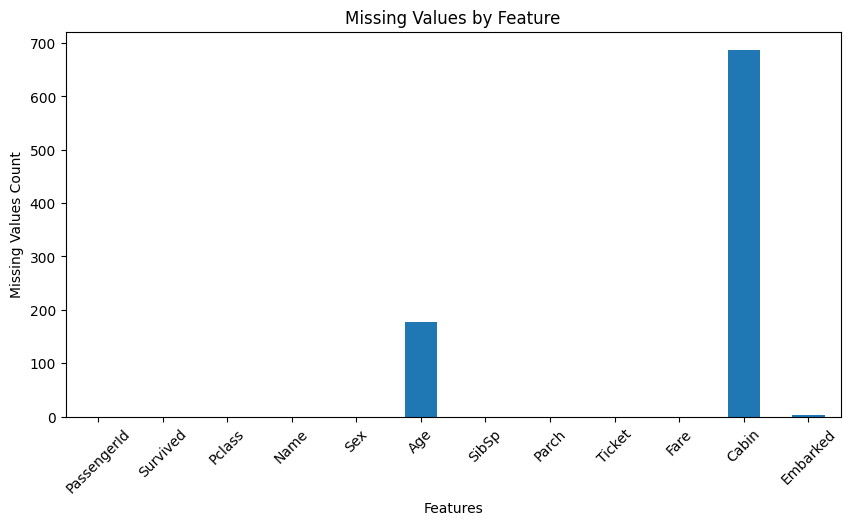

In [14]:
plt.figure(figsize = (10,5))
df.isnull().sum().plot (kind='bar')

plt.title("Missing Values by Feature")
plt.xlabel("Features")

plt.ylabel("Missing Values Count")
plt.xticks(rotation = 45)

plt.show()

In [15]:
print("Duplicate rows : " , df.duplicated().sum())

Duplicate rows :  0


In [19]:
df_mean  = df.copy()

mean_age = df_mean['Age'].mean()

df_mean['Age'] = df_mean['Age'].fillna(mean_age)

print("Remaining missing Age values : ", df_mean['Age'].isnull().sum())


Remaining missing Age values :  0


In [20]:
# Replace missing values by Median
df_median = df.copy()

median_age = df_median['Age'].median()

df_median['Age'] = df_median['Age'].fillna(median_age)

print("Remaining missing Age values : ", df_median['Age'].isnull().sum())

Remaining missing Age values :  0


In [21]:
print("Mean Age :", df['Age'].mean())

Mean Age : 29.69911764705882


In [22]:
print("Median Age :", df['Age'].median())

Median Age : 28.0


In [23]:
df_mode = df.copy()

mode_embarked = df_mode['Embarked'].mode()[0]

df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embarked)

print("Remaining missing Embarked values : ", df_mode['Embarked'].isnull().sum())

Remaining missing Embarked values :  0


In [24]:
print("Mode Embarked :", df['Embarked'].mode()[0])

Mode Embarked : S


In [32]:
print(df[['Sex', 'Embarked']].head(10))

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False , handle_unknown= 'ignore')

encoded = encoder.fit_transform(df[['Sex', 'Embarked']])

encoded_df = pd.DataFrame(encoded , columns = encoder.get_feature_names_out(['Sex' , 'Embarked']))

encoded_df.head()

      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Survived_encoded'] = label_encoder.fit_transform(df['Survived'])

df[['Survived', 'Survived_encoded']].head()


,Survived,Survived_encoded
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


In [33]:
#Min-Max Scaling
features = df[['Age', 'Fare']].dropna()

print(features.describe())

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

scaled_minmax = minmax.fit_transform(features)

minmax_df = pd.DataFrame(
    scaled_minmax,
    columns=['Age','Fare']
)

print(minmax_df.head())

              Age        Fare
count  714.000000  714.000000
mean    29.699118   34.694514
std     14.526497   52.918930
min      0.420000    0.000000
25%     20.125000    8.050000
50%     28.000000   15.741700
75%     38.000000   33.375000
max     80.000000  512.329200
        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713


In [34]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

scaled_standard = standard.fit_transform(features)

standard_df = pd.DataFrame(
    scaled_standard,
    columns=['Age','Fare']
)

print(standard_df.head())

        Age      Fare
0 -0.530377 -0.518978
1  0.571831  0.691897
2 -0.254825 -0.506214
3  0.365167  0.348049
4  0.365167 -0.503850
